# TP3 : Analyse en composantes principales (PCA)

Importez les bibliothèques suivantes.

In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Le TP précédent portait sur le K-clustering. Le présent TP utilisant les résultats de ce dernier, voici une cellule définissant la classe `MyKMeans` ainsi que la fonction `accuracy(labels)`.

In [3]:
def assign_clusters(data,centroids):
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def random_centroids(data,k):
    indices = np.random.choice(data.shape[0],k,replace=False)
    centroids = data[indices]
    return centroids

def update_centroids(data,k, labels):
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        points_in_cluster = data[labels == i]

        if len(points_in_cluster) > 0:
            new_centroids[i] = points_in_cluster.mean(axis=0)
        else:
            new_centroids[i] = data[np.random.choice(len(data))]

    return new_centroids

class MyKMeans:
    def __init__(self, n_clusters, max_iter=100, tol=1e-4):
        self.k = n_clusters
        self.max_iter = max_iter
        self.tol = tol

        self.centroids = None
        self.labels = None

    def fit(self, data):
        # 1. Init
        self.centroids = random_centroids(data,self.k)

        for i in range(self.max_iter):
            old_centroids = self.centroids.copy()
            self.labels = assign_clusters(data, self.centroids)
            self.centroids = update_centroids(data, self.k, self.labels)

            diff = np.linalg.norm(self.centroids - old_centroids)
            if diff < self.tol:
                print(f"Convergence atteinte à l'itération {i}")
                break
        else:
            print(f"Arrêt : Max itérations ({self.max_iter}) atteintes.")

        return self

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [4]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")

    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [5]:
from google.colab import files
data_to_load1 = files.upload()
import io
df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))


X = df_pixels.to_numpy(dtype="uint8")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

Saving labels.csv to labels.csv
Saving pixels.csv to pixels.csv


L'objectif de ce TP va consister en la définition progressive (par Monkey-Patching) d'une classe `MyPCA` implémentant l'alogirthme d'analyse en composantes principales.

In [6]:
class MyPCA:
    def __init__(self, n_components, standardize=False):

        self.n_components = n_components
        self.standardize = standardize

        self.mean = None
        self.std = None
        self.components = None
        self.explained_variance = None
        self.total_variance = None
        self.prepared_matrix = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1

1. La première étape est celle de préparation des données. Il existe deux versions de la PCA : la PCA sur la matrice de covariance (la matrice de données est centrée) et la PCA sur la matrice de corrélation (la matrice de données est centrée et réduite). Construisez une fonction `prepare_data(data,standardize=False)`qui renvoie une liste `prepared_data, mean, std' où:

- `prepared_data` est la matrice de données préparée pour la PCA (le booléen `standardize` determine quelle version est utilisée),
- `mean` est la donnée moyenne,
- `std` est l'écart-type (il faut la modifier légèrement ($0.00000001$ par exemple) pour assurer qu'elle n'est jamais 0).

In [7]:
def prepare_data(data, standardize=False):
    mean = data.mean()
    std = data.std() + 0.000000001
    if standardize:
        prepared_data = (data - mean) / std
    else:
        prepared_data = data - mean
    return [prepared_data, mean, std]

2. Une fois la matrice de données préparée, on l'utilise pour calculer la comatrice (matrice de covariance ou matrice de corrélation). Construisez une fonction `compute_comatrix(data_prepared)` renvoyant cette comatrice.

In [8]:
def compute_comatrix(data_prepared):
    (m, n) = data_prepared.shape
    return 1/(m-1) * np.dot((data_prepared.T),(data_prepared))

## Exercice 2

Une fois la comatrice calculée, on opère une décomposition spectrale pour récupérer ses valeurs propres et ses vecteurs propres. On peut ensuite choisir les $n$ composantes les plus importantes. Construisez une fonction `get_principal_components(comatrix, n_components)` qui renvoie une liste `top_eigenvalues, top_eigenvectors, total` où :

- `top_eigenvalues` est le vecteur de $n$ plus granges valeurs propres ordonnées de la plus petites à la plus grandes,
- `top_eigenvectors` est la matrice où chacune des $n$ lignes correspond à un vecteur propre et où ils sont ordonnés dans l'ordre correspondant à leurs valeurs propres respectives,
- `total` est la somme de toutes les valeurs propres.

Attention à l'ordre et aux dimensions de vos objets ! Utilisez la fonction `np.linalg.eigh` (**[documentation](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh)**).

In [9]:
def get_principal_components(comatrix, n_components):
    eigenvalues, eigenvectors = np.linalg.eigh(comatrix)

    idx = np.argsort(eigenvalues)

    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    top_eigenvalues = eigenvalues[-n_components:]
    top_eigenvectors = eigenvectors[:,-n_components:].T

    total = eigenvalues.sum()
    return (top_eigenvalues, top_eigenvectors, total)

## Exercice 3

Nous allons maintenant achever la définition de la classe `MyPCA`.

1. Construisez et attribuer à `MyPCA` une fonction `fit(self,data)` appliquant une PCA à la matrice `data`. Il va s'agir d'assigner les 6 attributs de la classe `MyPCA` qui ne l'ont pas été à l'initialisation.

In [10]:
def fit(self, data):
    (self.prepared_matrix, self.mean, self.std) = prepare_data(data, self.standardize)

    comatrix = compute_comatrix(self.prepared_matrix)

    (top_eigenvalues, self.components, self.total_variance) = get_principal_components(comatrix, self.n_components)
    self.explained_variance = top_eigenvalues/self.total_variance


MyPCA.fit = fit

2. Construisez et attribuez à `MyPCA` une fonction `transform(self,data)` renvoyant la projection de la matrice `data` dans l'espace des composantes principales de l'instance de la classe.

In [11]:

def transform(self, data):
    X = data - self.mean
    if self.standardize:
        X = X / self.std
    return np.dot(X, self.components.T)
MyPCA.transform = transform


3. Construisez et attribuez à `MyPCA` une fonction `inverse_transform(self,data_projected)` renvoyant la reconstruction dans l'espace original d'une matrice de données vivant dans l'espace des composantes principales de l'instance de la classe.

In [12]:
def inverse_transform(self, data_projected):
    if (self.standardize) :
        return self.std * np.dot(data_projected, self.components) + self.mean
    else :
        return np.dot(data_projected, self.components) + self.mean

MyPCA.inverse_transform = inverse_transform

## Exercice 4

1. Créez une instance de la classe `MyPCA` afin de faire une PCA sur nos données (`X`) avec 6 composantes principles. Affichez les images correspondants aux 6 composantes principales.

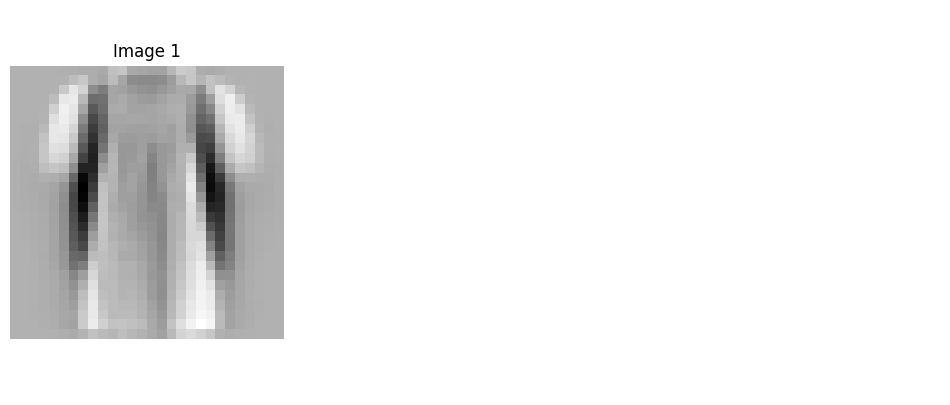

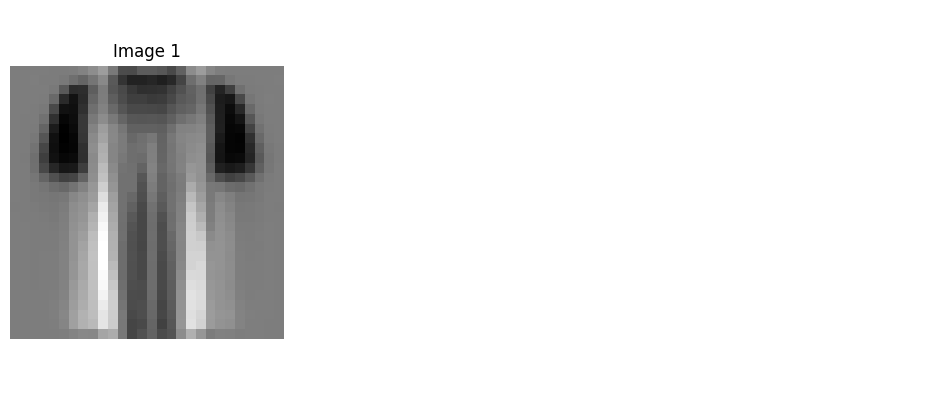

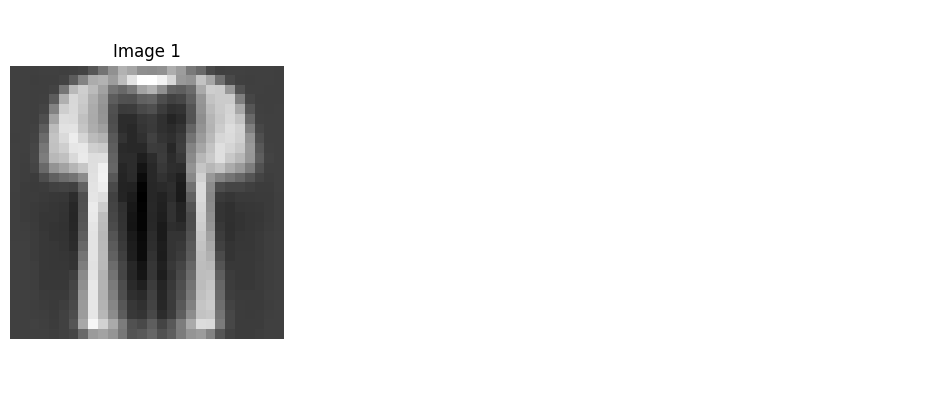

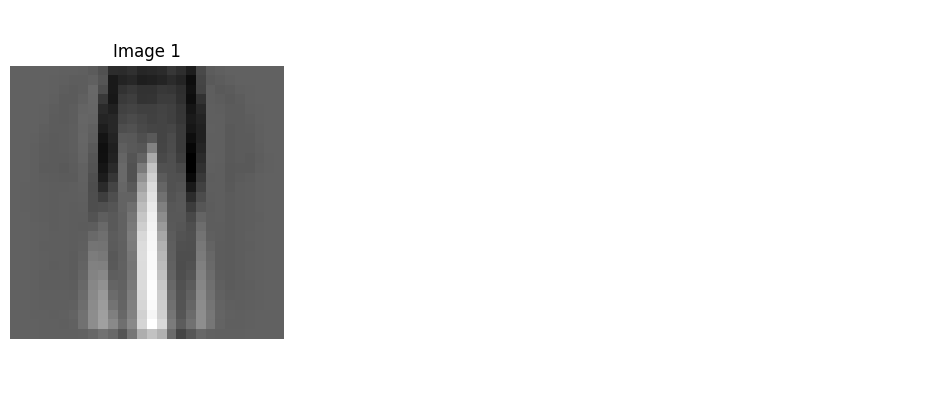

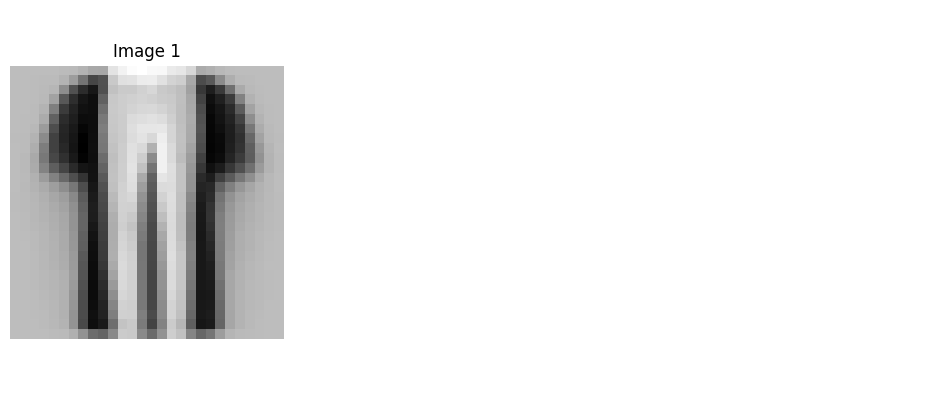

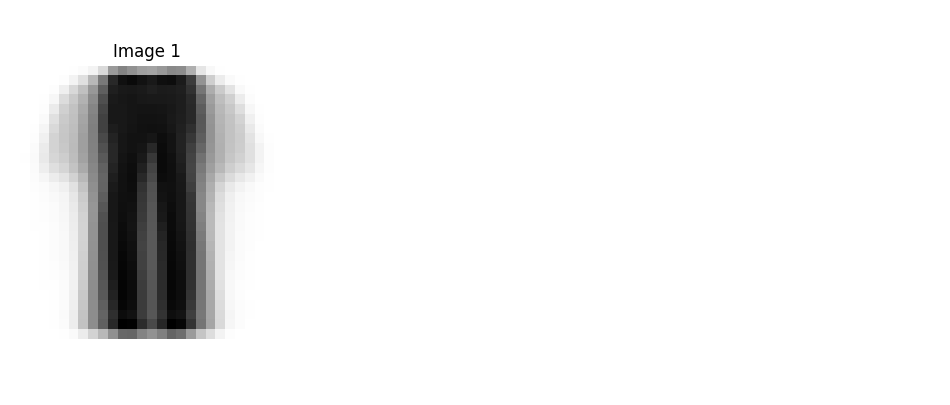

In [13]:

instance = MyPCA(n_components=6, standardize=False)
instance.fit(X)

for vect in instance.components:
    display_image(vect)


2. Dessiner un graphique représentant, pour $i$ allant de 1 à 100, la part de la variance expliquée par les $i$ premières composantes principales. Utilisez `plt.plot` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)**).

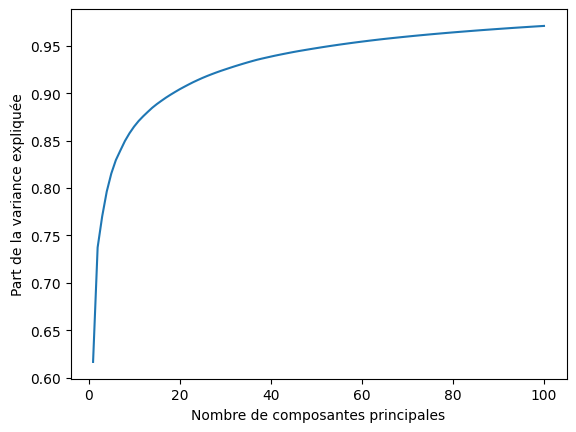

In [14]:

tab_var_exp = []

for i in range(1, 101):
    instance = MyPCA(n_components=i, standardize=False)
    instance.fit(X)
    tab_var_exp.append(np.sum(instance.explained_variance))

plt.plot(range(1, 101), tab_var_exp)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Part de la variance expliquée")
plt.show()


3. Choisissez une image dans nos données. Affichez là avec ses compressions (projection puis reconstruction) dans les $i$ premières composantes principales, pour $i$ prenant les valeurs 1,3,5,10,25,50,75 et 100.

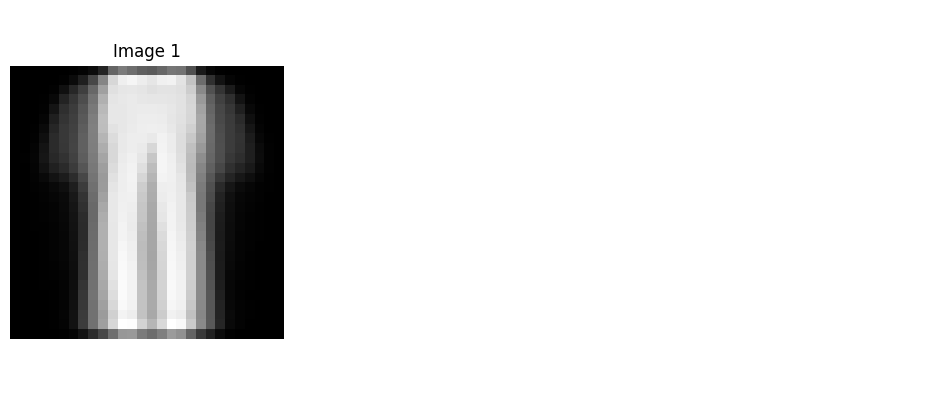

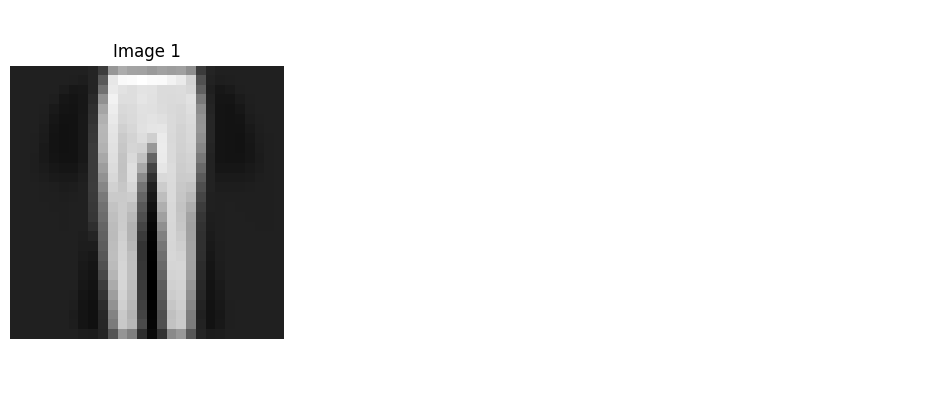

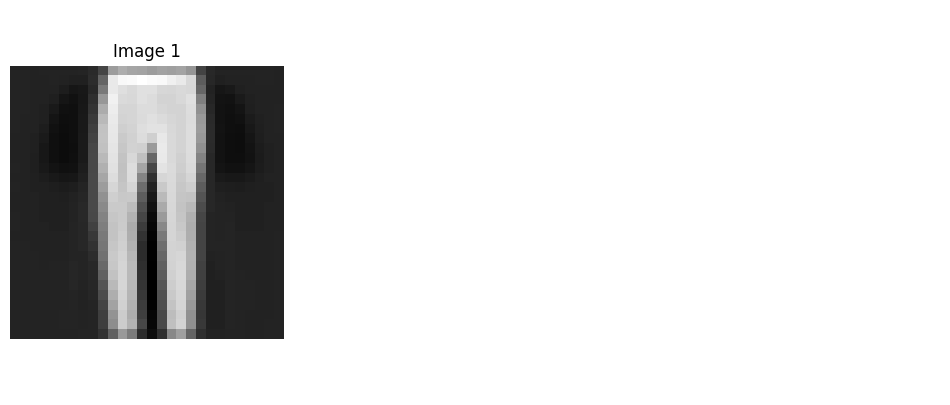

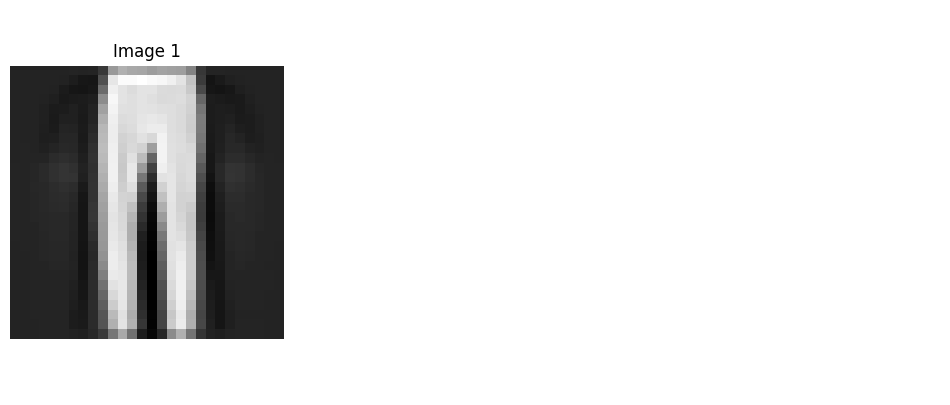

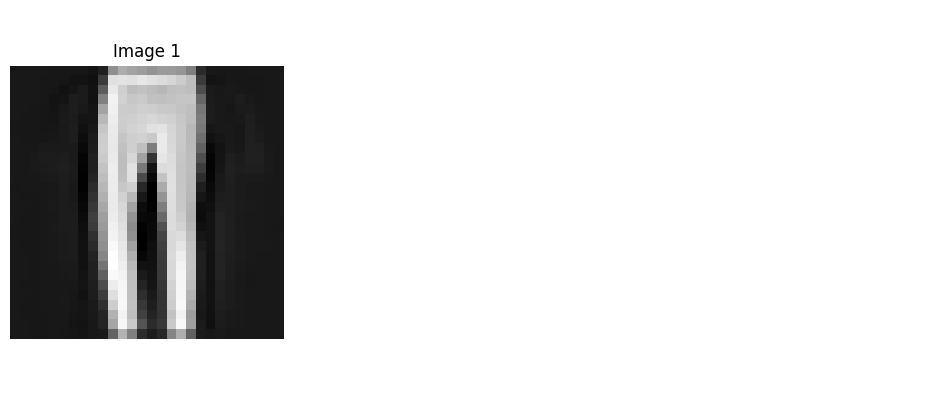

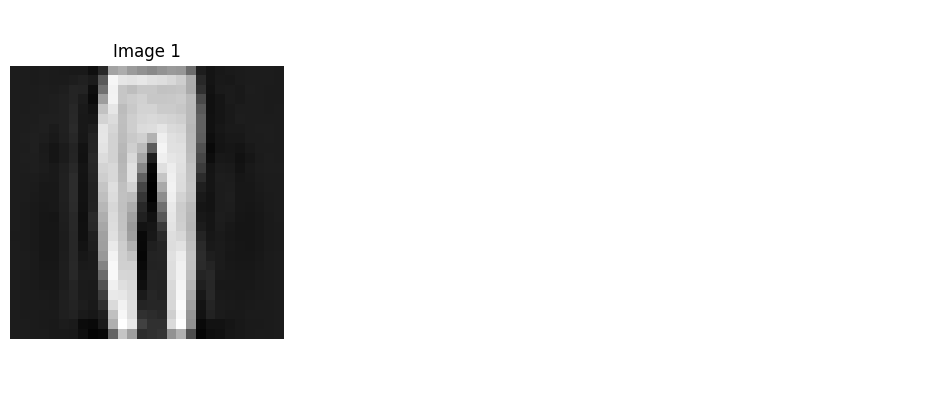

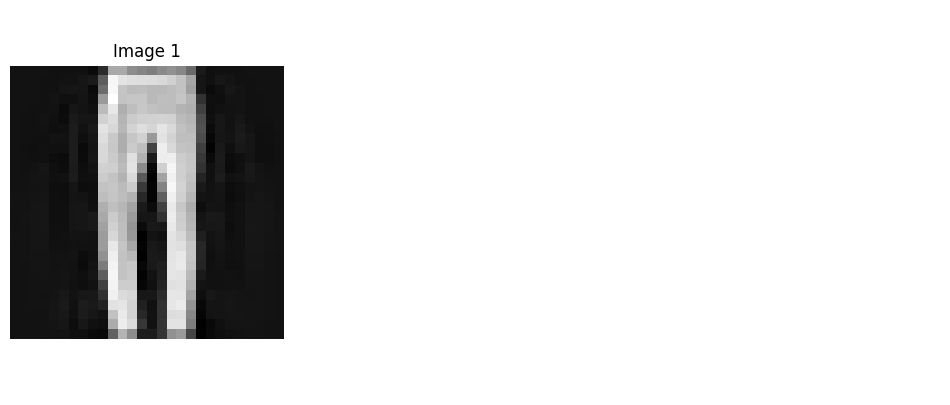

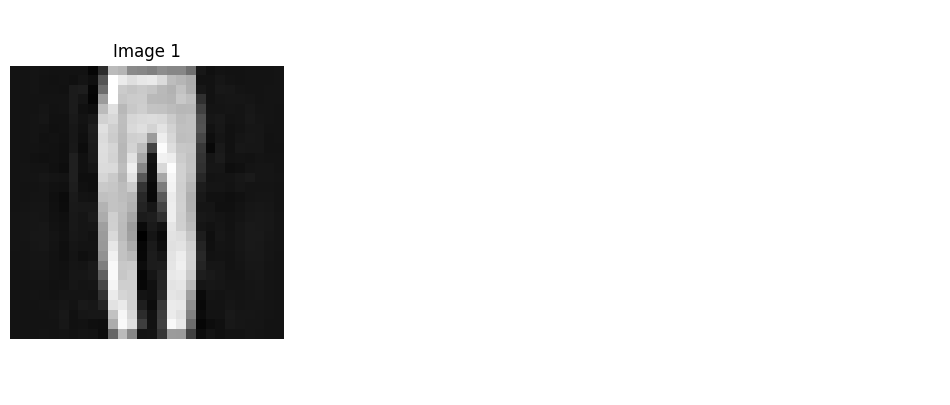

In [15]:

img = X[0]

for i in [1, 3, 5, 10, 25, 50, 75, 100]:
    instance = MyPCA(n_components=i, standardize=False)
    instance.fit(X)

    img_projected = instance.transform(img.reshape(1, -1))
    img_reconstructed = instance.inverse_transform(img_projected)

    display_image(img_reconstructed[0])


## Exercice 5

1. Utilisez la classe `MyPCA` pour projeter `X` sur deux dimensions. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**).

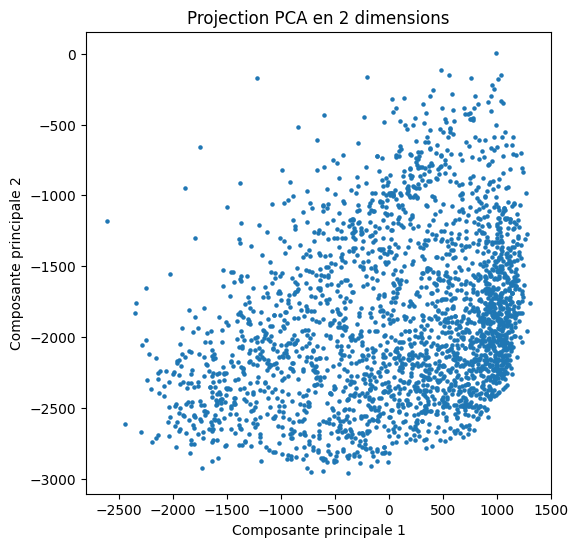

In [16]:
instance = MyPCA(n_components=2, standardize=False)
instance.fit(X)

X_proj = instance.transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_proj[:, 0], X_proj[:, 1], s=5)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA en 2 dimensions")
plt.show()


2. Dans ce nuage de points, colorez chaque point en fonction de son véritable label (le vecteur de labels est `y`).

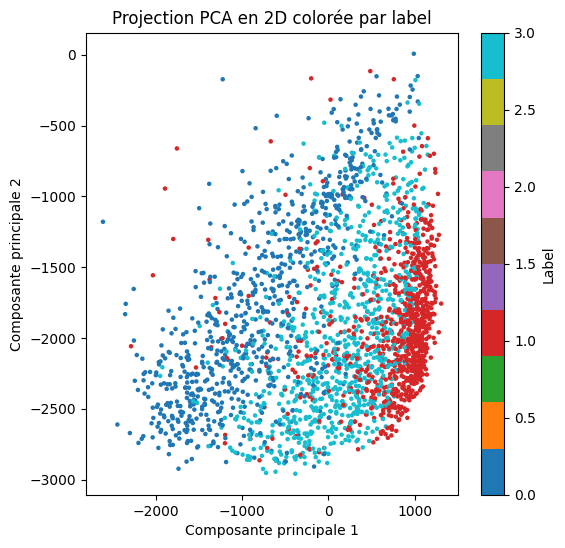

In [17]:
instance = MyPCA(n_components=2, standardize=False)
instance.fit(X)

X_proj = instance.transform(X)

plt.figure(figsize=(6,6))
plt.scatter(
    X_proj[:, 0],
    X_proj[:, 1],
    c=y,
    cmap="tab10",
    s=5
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA en 2D colorée par label")
plt.colorbar(label="Label")
plt.show()


3. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de `X` avec 3 clusters. Affichez les images correspondants aux centroïdes.

Convergence atteinte à l'itération 15


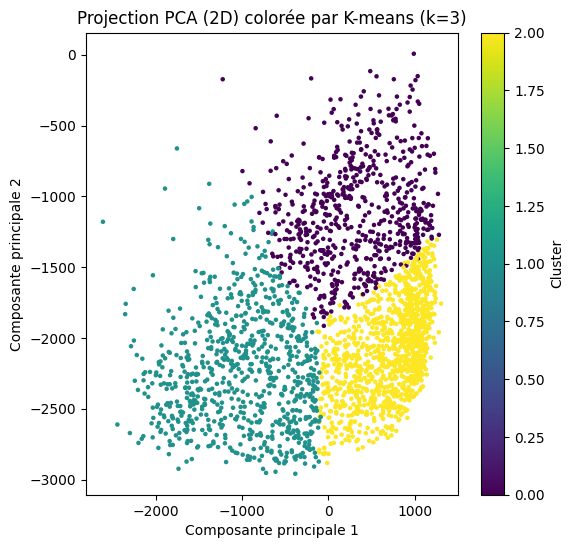

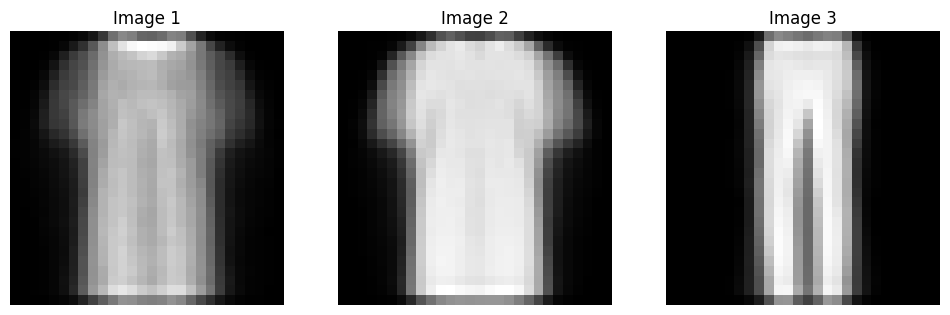

In [18]:

kmeans = MyKMeans(n_clusters=3)
kmeans.fit(X)

labels_kmeans = kmeans.labels
centroids = kmeans.centroids

pca = MyPCA(n_components=2, standardize=False)
pca.fit(X)
X_proj = pca.transform(X)


plt.figure(figsize=(6,6))
plt.scatter(
    X_proj[:, 0],
    X_proj[:, 1],
    c=labels_kmeans,
    cmap="viridis",
    s=5
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA (2D) colorée par K-means (k=3)")
plt.colorbar(label="Cluster")
plt.show()

display_image(centroids)


4. Enfin, changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection PCA de `X` en 2 dimensions, avec 3 clusters. Affichez les images correspondants aux centroïdes.

Convergence atteinte à l'itération 37


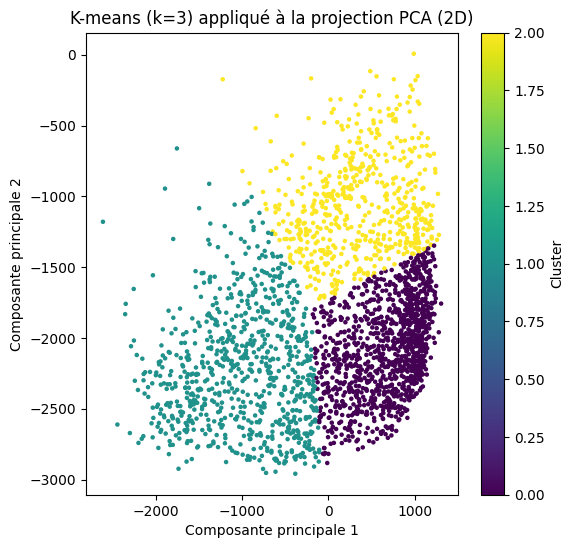

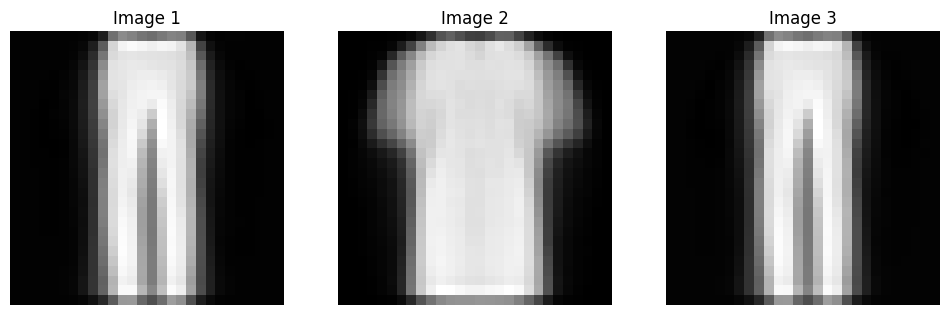

In [19]:

pca = MyPCA(n_components=2, standardize=False)
pca.fit(X)
X_proj = pca.transform(X)


kmeans_pca = MyKMeans(n_clusters=3)
kmeans_pca.fit(X_proj)

labels_kmeans_pca = kmeans_pca.labels
centroids_pca = kmeans_pca.centroids


plt.figure(figsize=(6,6))
plt.scatter(
    X_proj[:, 0],
    X_proj[:, 1],
    c=labels_kmeans_pca,
    cmap="viridis",
    s=5
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("K-means (k=3) appliqué à la projection PCA (2D)")
plt.colorbar(label="Cluster")
plt.show()

centroids_reconstructed = pca.inverse_transform(centroids_pca)

display_image(centroids_reconstructed)


## Exercice 6

1. Dessinez un graphe calculant la précision (`accuracy`) des labels obtenus par un K-clusterings de la projection PCA de `X` dans ses $i$ premières composantes principales avec 3 clusters, pour $i$ allant de 1 à 40. Utilisez `plt.plot`.

Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 25
Convergence atteinte à l'itération 32
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 27
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 27
Convergence atteinte à l'itération 27
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 13
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 8
Convergence atteinte à l'itération 39
Convergence atteinte à l'itération 13
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 16
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 19
Convergence a

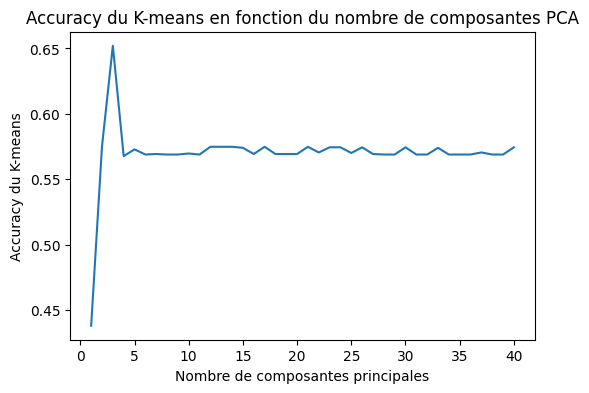

In [20]:
tab_accuracy = []

for i in range(1, 41):

    pca = MyPCA(n_components=i, standardize=False)
    pca.fit(X)
    X_proj = pca.transform(X)

    kmeans = MyKMeans(n_clusters=3)
    kmeans.fit(X_proj)

    acc = accuracy(kmeans.labels)
    tab_accuracy.append(acc)

plt.figure(figsize=(6,4))
plt.plot(range(1, 41), tab_accuracy)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Accuracy du K-means")
plt.title("Accuracy du K-means en fonction du nombre de composantes PCA")
plt.show()


2. Faîtes la même chose mais avec 20 clusters.

Convergence atteinte à l'itération 65
Convergence atteinte à l'itération 66
Convergence atteinte à l'itération 45
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 51
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 28
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 34
Convergence atteinte à l'itération 40
Convergence atteinte à l'itération 36
Convergence atteinte à l'itération 51
Convergence atteinte à l'itération 44
Convergence atteinte à l'itération 39
Convergence atteinte à l'itération 40
Convergence atteinte à l'itération 25
Convergence atteinte à l'itération 46
Convergence atteinte à l'itération 26
Convergence atteinte à l'itération 34
Convergence atteinte à l'itération 21
Convergence atteinte à l'itération 22
Convergence atteinte à l'itération 37
Convergence atteinte à l'itération 36
Convergence atteinte à l'itération 40
Convergence 

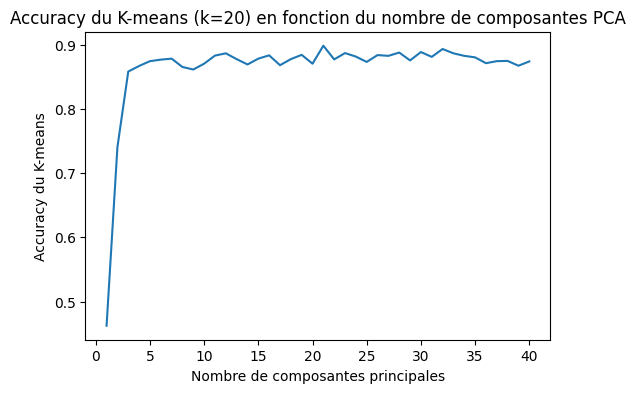

In [21]:
tab_accuracy = []

for i in range(1, 41):

    pca = MyPCA(n_components=i, standardize=False)
    pca.fit(X)
    X_proj = pca.transform(X)


    kmeans = MyKMeans(n_clusters=20)
    kmeans.fit(X_proj)


    acc = accuracy(kmeans.labels)
    tab_accuracy.append(acc)

plt.figure(figsize=(6,4))
plt.plot(range(1, 41), tab_accuracy)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Accuracy du K-means")
plt.title("Accuracy du K-means (k=20) en fonction du nombre de composantes PCA")
plt.show()


3. Calculez la précision des labels issus d'un K-clustering de `X` avec 100 clusters.

In [22]:
kmeans = MyKMeans(n_clusters=100)
kmeans.fit(X)

acc = accuracy(kmeans.labels)
print("Accuracy du K-means sur X avec 100 clusters :", acc)


Convergence atteinte à l'itération 23
Accuracy du K-means sur X avec 100 clusters : 0.9084812623274162


4. Calculez la précision des labels issus d'un K-clustering de la projection de `X` dans ses 50 premières composantes principales avec 100 clusters. Même chose avec 100 composantes principales. Qu'observez-vous ?

In [23]:

pca_50 = MyPCA(n_components=50, standardize=False)
pca_50.fit(X)
X_proj_50 = pca_50.transform(X)


kmeans_50 = MyKMeans(n_clusters=100)
kmeans_50.fit(X_proj_50)

acc_50 = accuracy(kmeans_50.labels)
print("Accuracy PCA 50 composantes + K-means 100 clusters :", acc_50)

pca_100 = MyPCA(n_components=100, standardize=False)
pca_100.fit(X)
X_proj_100 = pca_100.transform(X)

kmeans_100 = MyKMeans(n_clusters=100)
kmeans_100.fit(X_proj_100)

acc_100 = accuracy(kmeans_100.labels)
print("Accuracy PCA 100 composantes + K-means 100 clusters :", acc_100)



Convergence atteinte à l'itération 16
Accuracy PCA 50 composantes + K-means 100 clusters : 0.9254437869822485
Convergence atteinte à l'itération 14
Accuracy PCA 100 composantes + K-means 100 clusters : 0.9242603550295858


## Exercice 7

Refaites les exercices 4, 5 et 6 avec `standardize=True`. Quelles différences observez-vous ? Comment pouvez-vous les expliquer ? Quelle version faut-il choisir ici ?

In [23]:
Avec standardize=True, la projection PCA est plus
équilibrée et les points sont mieux répartis.
Les images reconstruites sont un peu moins nettes mais
représentent mieux la forme générale des chiffres.
Cela s’explique par le fait que la standardisation met tous les pixels sur la même échelle.
Sans standardisation, certains pixels avec une forte
variance dominent la PCA.
Ici, la version avec standardize=True est à privilégier
car elle donne des résultats plus stables et plus cohérents
pour la visualisation et le clustering.

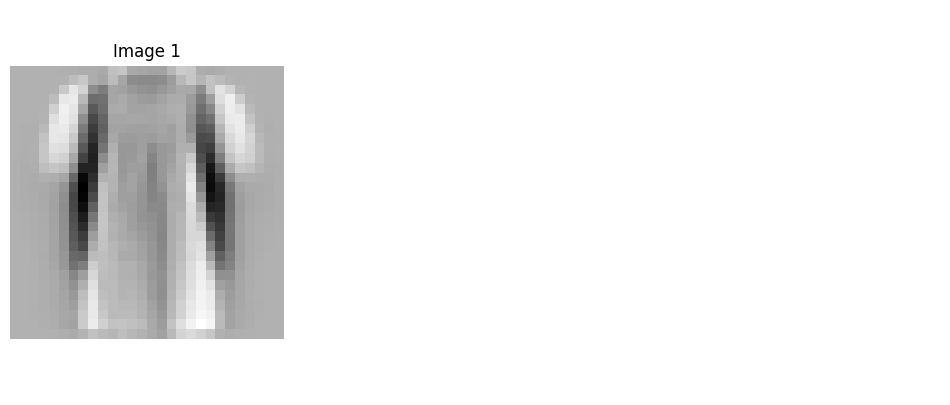

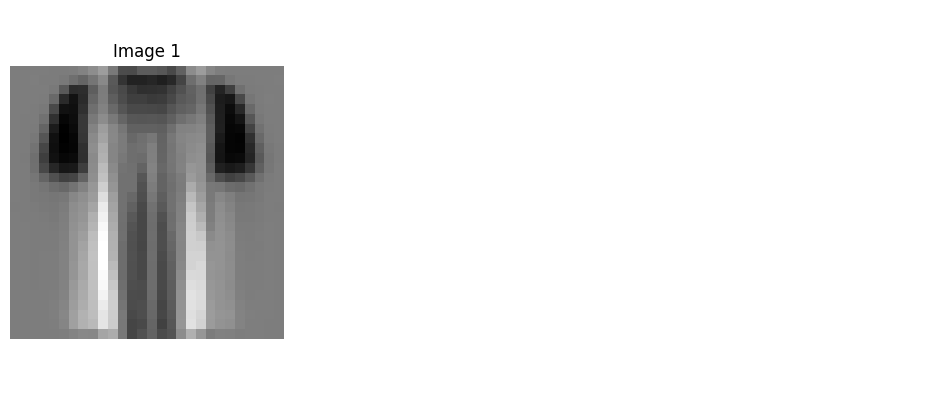

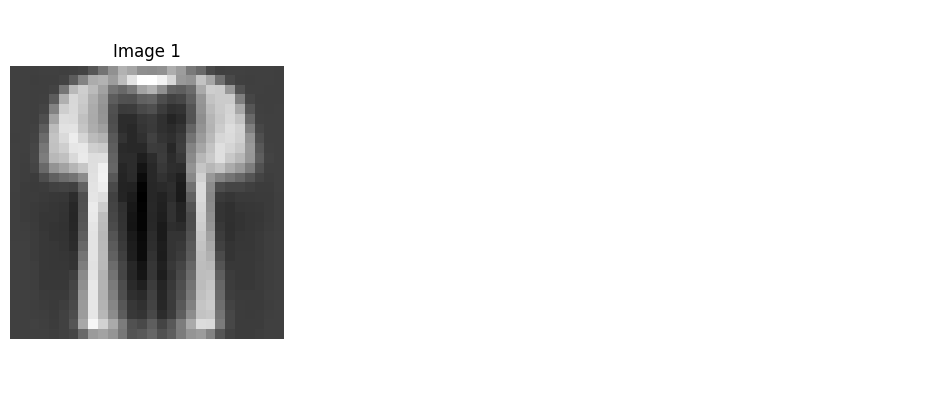

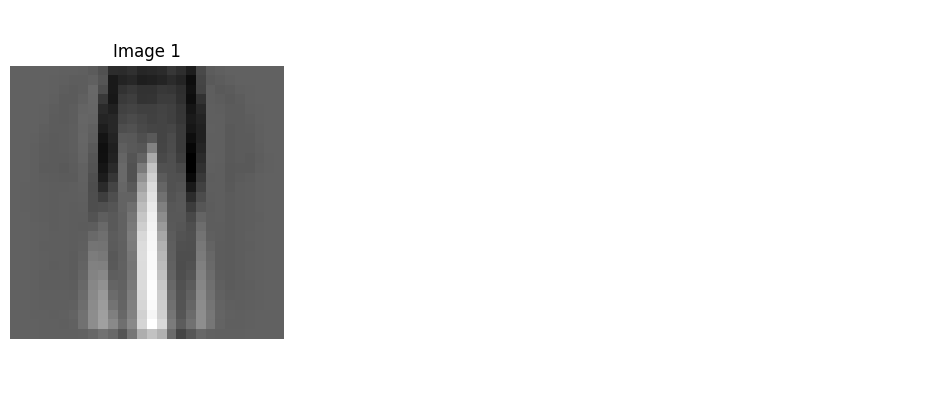

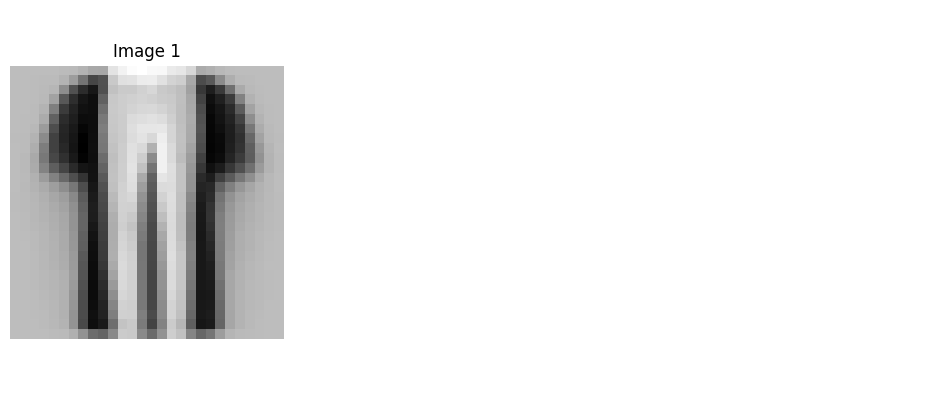

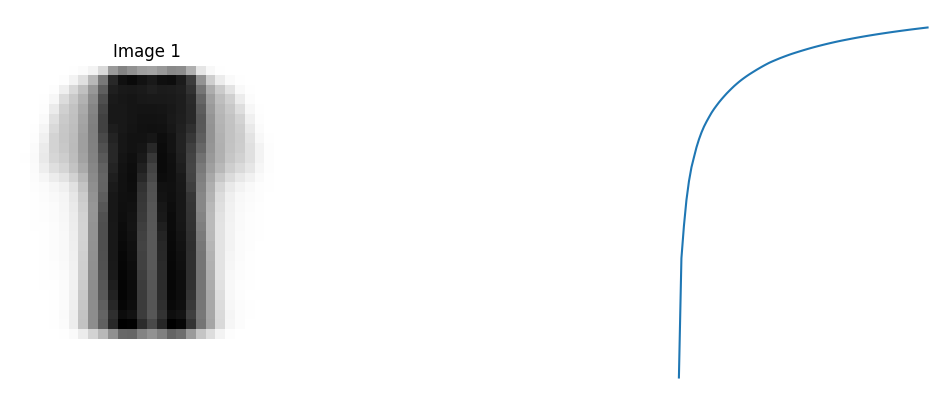

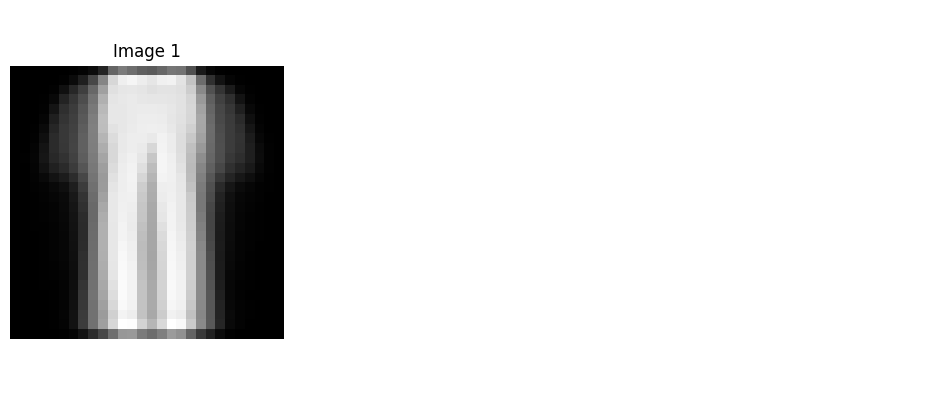

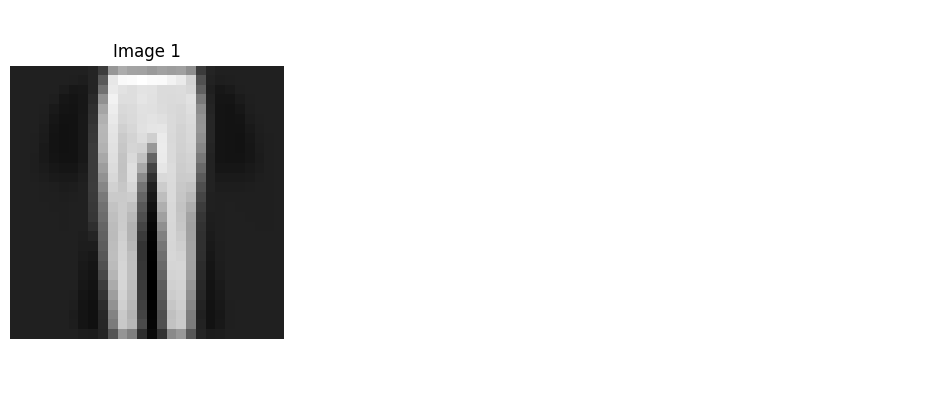

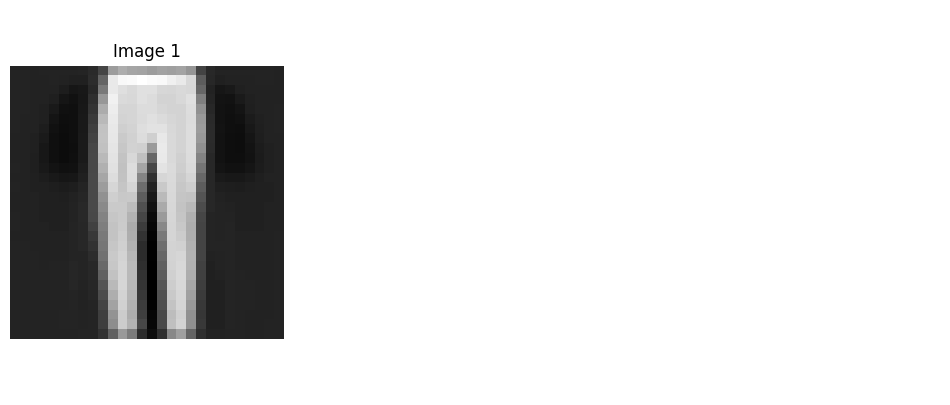

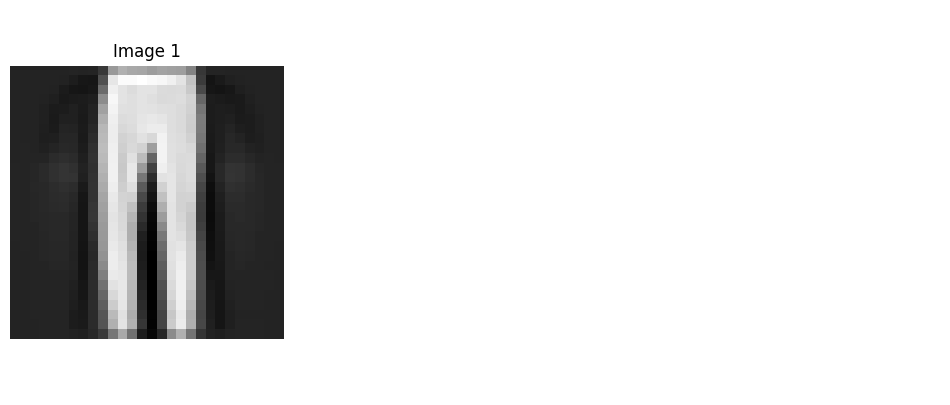

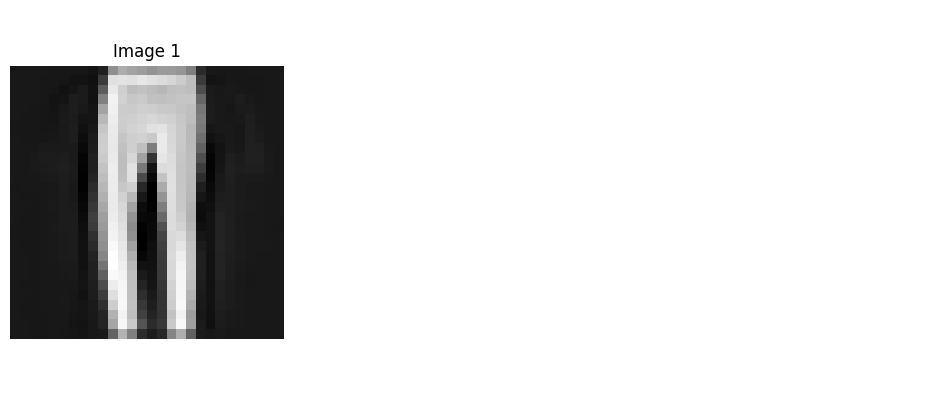

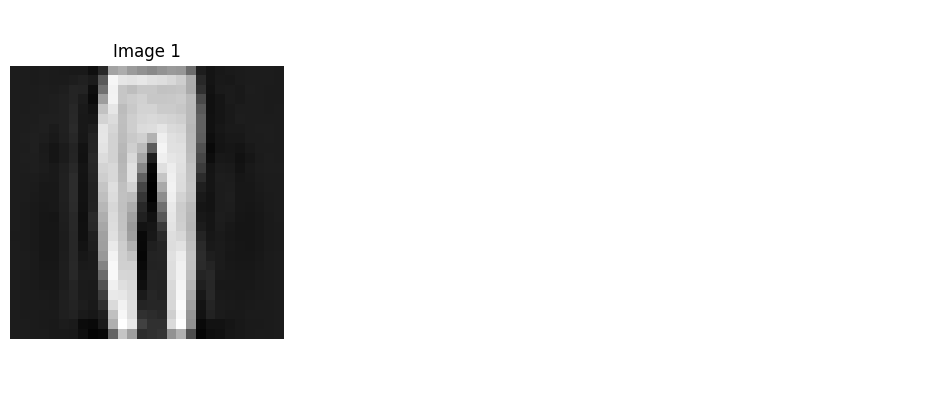

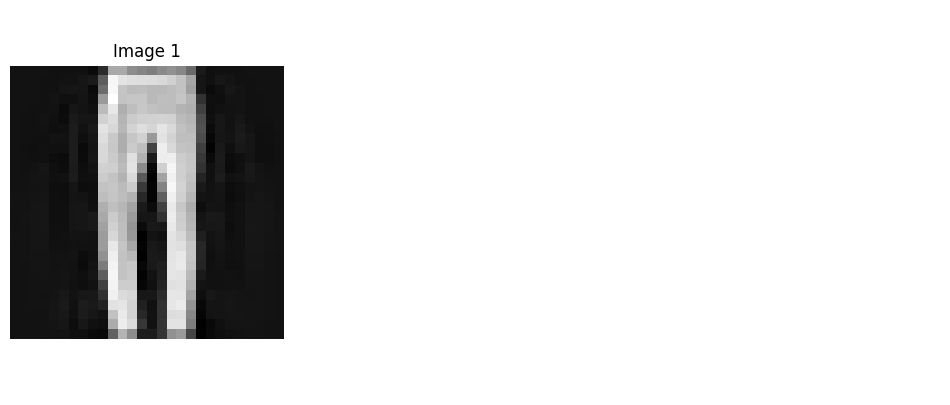

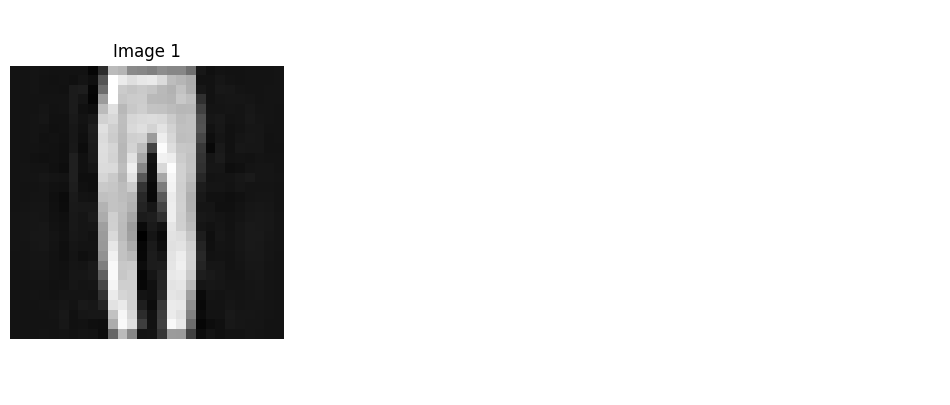

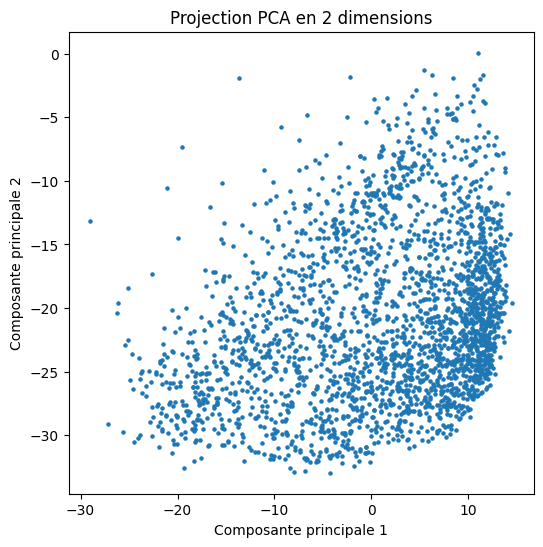

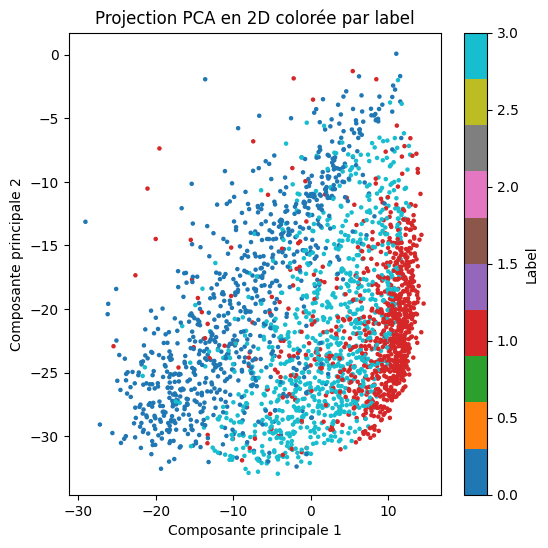

Convergence atteinte à l'itération 29


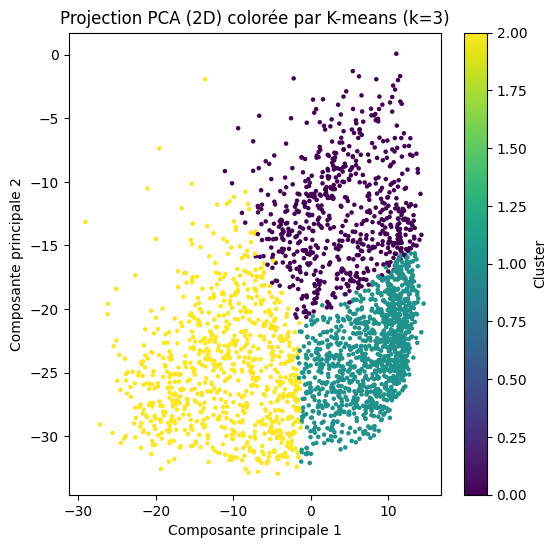

Convergence atteinte à l'itération 19


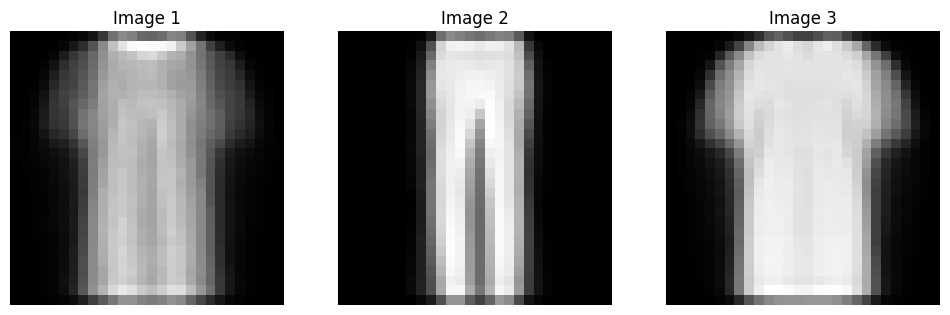

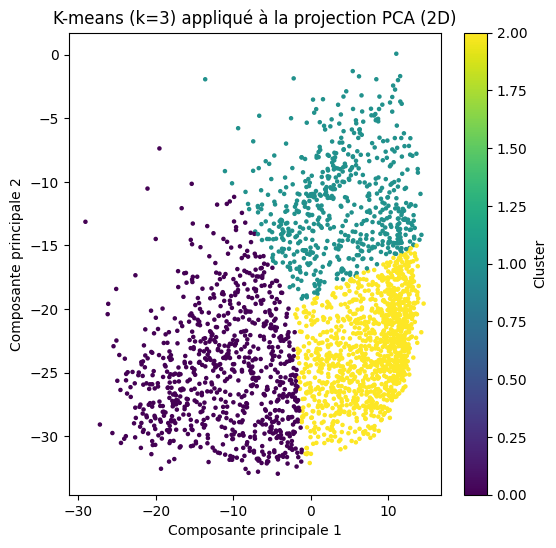

Convergence atteinte à l'itération 13
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 9
Convergence atteinte à l'itération 20
Convergence atteinte à l'itération 17
Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 14
Convergence atteinte à l'itération 8
Convergence atteinte à l'itération 34
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 25
Convergence atteinte à l'itération 9
Convergence atteinte à l'itération 18
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 11
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 35
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 13
Convergence atteinte à l'itération 15
Convergence atteinte à l'itération 33
Convergence atteinte à l'itération 12
Convergence atteinte à l'itération 13
Convergence att

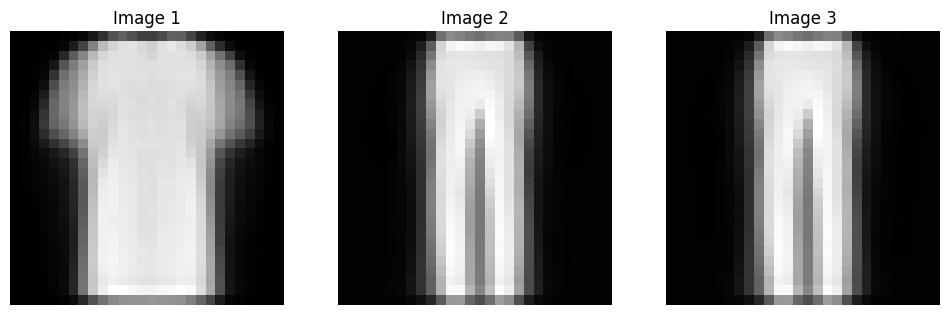

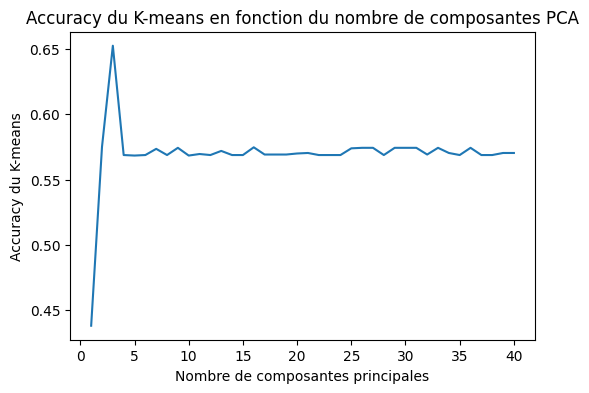

Convergence atteinte à l'itération 51
Convergence atteinte à l'itération 93
Convergence atteinte à l'itération 55
Convergence atteinte à l'itération 29
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 29
Convergence atteinte à l'itération 25
Convergence atteinte à l'itération 38
Convergence atteinte à l'itération 27
Convergence atteinte à l'itération 25
Convergence atteinte à l'itération 31
Convergence atteinte à l'itération 30
Convergence atteinte à l'itération 32
Convergence atteinte à l'itération 44
Convergence atteinte à l'itération 49
Convergence atteinte à l'itération 24
Convergence atteinte à l'itération 23
Convergence atteinte à l'itération 29
Convergence atteinte à l'itération 59
Convergence atteinte à l'itération 29
Convergence atteinte à l'itération 19
Convergence atteinte à l'itération 48
Convergence atteinte à l'itération 46
Convergence atteinte à l'itération 42
Convergence atteinte à l'itération 24
Convergence atteinte à l'itération 27
Convergence 

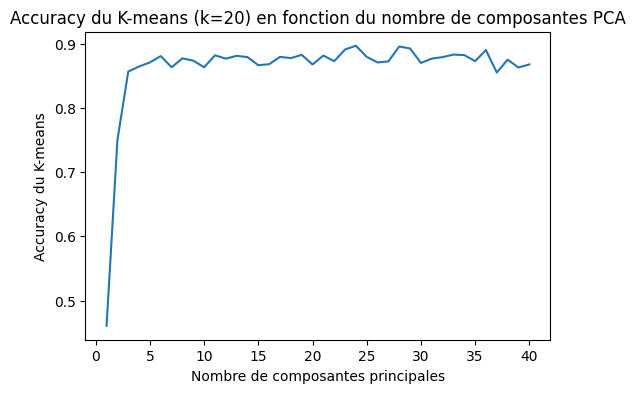

Convergence atteinte à l'itération 14
Accuracy du K-means sur X avec 100 clusters : 0.9179487179487179
Convergence atteinte à l'itération 18
Accuracy PCA 50 composantes + K-means 100 clusters : 0.9274161735700197
Convergence atteinte à l'itération 18
Accuracy PCA 100 composantes + K-means 100 clusters : 0.9321499013806707


In [25]:
instance = MyPCA(n_components=6, standardize=True)
instance.fit(X)

for vect in instance.components:
    display_image(vect)

tab_var_exp = []

for i in range(1, 101):
    instance = MyPCA(n_components=i, standardize=True)
    instance.fit(X)


    tab_var_exp.append(np.sum(instance.explained_variance))

plt.plot(range(1, 101), tab_var_exp)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Part de la variance expliquée")
plt.show()
img = X[0]

for i in [1, 3, 5, 10, 25, 50, 75, 100]:
    instance = MyPCA(n_components=i, standardize=True)
    instance.fit(X)

    img_projected = instance.transform(img.reshape(1, -1))
    img_reconstructed = instance.inverse_transform(img_projected)

    display_image(img_reconstructed[0])

instance = MyPCA(n_components=2, standardize=True)
instance.fit(X)

X_proj = instance.transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_proj[:, 0], X_proj[:, 1], s=5)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA en 2 dimensions")
plt.show()
instance = MyPCA(n_components=2, standardize=True)
instance.fit(X)

X_proj = instance.transform(X)

plt.figure(figsize=(6,6))
plt.scatter(
    X_proj[:, 0],
    X_proj[:, 1],
    c=y,
    cmap="tab10",
    s=5
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA en 2D colorée par label")
plt.colorbar(label="Label")
plt.show()

kmeans = MyKMeans(n_clusters=3)
kmeans.fit(X)

labels_kmeans = kmeans.labels
centroids = kmeans.centroids


pca = MyPCA(n_components=2, standardize=True)
pca.fit(X)
X_proj = pca.transform(X)


plt.figure(figsize=(6,6))
plt.scatter(
    X_proj[:, 0],
    X_proj[:, 1],
    c=labels_kmeans,
    cmap="viridis",
    s=5
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA (2D) colorée par K-means (k=3)")
plt.colorbar(label="Cluster")
plt.show()

# 4) Affichage des centroïdes
display_image(centroids)
# 1) PCA en 2 dimensions
pca = MyPCA(n_components=2, standardize=True)
pca.fit(X)
X_proj = pca.transform(X)

# 2) K-means avec 3 clusters sur la projection PCA
kmeans_pca = MyKMeans(n_clusters=3)
kmeans_pca.fit(X_proj)

labels_kmeans_pca = kmeans_pca.labels
centroids_pca = kmeans_pca.centroids

# 3) Nuage de points PCA coloré par clusters (K-means sur PCA)
plt.figure(figsize=(6,6))
plt.scatter(
    X_proj[:, 0],
    X_proj[:, 1],
    c=labels_kmeans_pca,
    cmap="viridis",
    s=5
)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("K-means (k=3) appliqué à la projection PCA (2D)")
plt.colorbar(label="Cluster")
plt.show()
# 4) reconstruction des centroïdes PCA vers l'espace image
centroids_reconstructed = pca.inverse_transform(centroids_pca)

# 5) affichage des images correspondantes
display_image(centroids_reconstructed)
tab_accuracy = []

for i in range(1, 41):
    # 1) PCA avec i composantes
    pca = MyPCA(n_components=i, standardize=True)
    pca.fit(X)
    X_proj = pca.transform(X)

    # 2) k-means (k=3) sur la projection PCA
    kmeans = MyKMeans(n_clusters=3)
    kmeans.fit(X_proj)

    # 3) accuracy du clustering
    acc = accuracy(kmeans.labels)
    tab_accuracy.append(acc)

plt.figure(figsize=(6,4))
plt.plot(range(1, 41), tab_accuracy)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Accuracy du K-means")
plt.title("Accuracy du K-means en fonction du nombre de composantes PCA")
plt.show()
tab_accuracy = []

for i in range(1, 41):
    # 1) PCA avec i composantes
    pca = MyPCA(n_components=i, standardize=True)
    pca.fit(X)
    X_proj = pca.transform(X)

    # 2) k-means (k=20) sur la projection PCA
    kmeans = MyKMeans(n_clusters=20)
    kmeans.fit(X_proj)

    # 3) accuracy du clustering
    acc = accuracy(kmeans.labels)
    tab_accuracy.append(acc)

# graphe
plt.figure(figsize=(6,4))
plt.plot(range(1, 41), tab_accuracy)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Accuracy du K-means")
plt.title("Accuracy du K-means (k=20) en fonction du nombre de composantes PCA")
plt.show()
kmeans = MyKMeans(n_clusters=100)
kmeans.fit(X)

acc = accuracy(kmeans.labels)
print("Accuracy du K-means sur X avec 100 clusters :", acc)
# PCA avec 50 composantes
pca_50 = MyPCA(n_components=50, standardize=True)
pca_50.fit(X)
X_proj_50 = pca_50.transform(X)

# k-means avec 100 clusters
kmeans_50 = MyKMeans(n_clusters=100)
kmeans_50.fit(X_proj_50)

acc_50 = accuracy(kmeans_50.labels)
print("Accuracy PCA 50 composantes + K-means 100 clusters :", acc_50)
# PCA avec 100 composantes
pca_100 = MyPCA(n_components=100, standardize=True)
pca_100.fit(X)
X_proj_100 = pca_100.transform(X)

# k-means avec 100 clusters
kmeans_100 = MyKMeans(n_clusters=100)
kmeans_100.fit(X_proj_100)

acc_100 = accuracy(kmeans_100.labels)
print("Accuracy PCA 100 composantes et K-means 100 clusters :", acc_100)

## Exercice 8

Quels intérêts et quels inconvénients y a t-il à faire son K-clustering sur des données projetées sur ses $n$ premiers composantes principales au lieu de le faire sur les données non-traitées ? Comment choisir $n$ ?

Écrivez votre réponse ici.